#Dataset Exploration

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!unzip "/content/drive/MyDrive/Colab Notebooks/Học máy/A/data.zip" -d "/content/data"

Archive:  /content/drive/MyDrive/Colab Notebooks/Học máy/A/data.zip
  inflating: /content/data/holidays_events.csv  
  inflating: /content/data/oil.csv   
  inflating: /content/data/sample_submission.csv  
  inflating: /content/data/stores.csv  
  inflating: /content/data/test.csv  
  inflating: /content/data/train.csv  
  inflating: /content/data/transactions.csv  


In [ ]:

df = pd.read_csv('data/train.csv')

In [ ]:
df

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.000,0
1,1,2013-01-01,1,BABY CARE,0.000,0
2,2,2013-01-01,1,BEAUTY,0.000,0
3,3,2013-01-01,1,BEVERAGES,0.000,0
4,4,2013-01-01,1,BOOKS,0.000,0
...,...,...,...,...,...,...
3000883,3000883,2017-08-15,9,POULTRY,438.133,0
3000884,3000884,2017-08-15,9,PREPARED FOODS,154.553,1
3000885,3000885,2017-08-15,9,PRODUCE,2419.729,148
3000886,3000886,2017-08-15,9,SCHOOL AND OFFICE SUPPLIES,121.000,8


In [ ]:
sales_2017_08_15 = (
    df[df['date'] == '2017-08-15']
    .sort_values(['store_nbr', 'family'])
    [['store_nbr', 'family', 'sales']]
)

display(sales_2017_08_15)

,store_nbr,family,sales
2999106,1,AUTOMOTIVE,4.000
2999107,1,BABY CARE,0.000
2999108,1,BEAUTY,4.000
2999109,1,BEVERAGES,1942.000
2999110,1,BOOKS,0.000
...,...,...,...
3000751,54,POULTRY,59.619
3000752,54,PREPARED FOODS,94.000
3000753,54,PRODUCE,915.371
3000754,54,SCHOOL AND OFFICE SUPPLIES,0.000


Có nhiều cửa hàng khác nhau thuộc các gia đình khác nhau. Như vậy, có thể sử dụng cùng 1 cửa hàng cùng 1 ngày nhưng khác loại mặt hàng


=> Dự đoán doanh số cho mỗi cửa hàng, mỗi dòng sản phẩm hoặc mỗi danh mục và mỗi ngày cụ thể.

=> Dự đoán co từng chuỗi thời gian riêng lẻ, có nghĩa là: có dố lượng cửa hàng, số lượng gia đình : các chuỗi tgian khác nhau mà phải dự đoán

In [ ]:
df.family.value_counts()

,count
family,
AUTOMOTIVE,90936
BABY CARE,90936
BEAUTY,90936
BEVERAGES,90936
BOOKS,90936
BREAD/BAKERY,90936
CELEBRATION,90936
CLEANING,90936
DAIRY,90936


In [ ]:
# X input channels with 120 data point each => model => X output channels with 16 data points each



In [ ]:
len(df.family.unique())

33

In [ ]:
len(df.store_nbr.unique())

54

In [ ]:
33 * 54    # Số lượng chuỗi thời gian mà ta phải đưa ra dự đoán (mỗi chuỗi thời gian đại diện cho dữ liệu bán hàng của một danh mục sản phẩm cụ thể được bán tại một cửa hàng cụ thể)

1782

In [ ]:
df['store_family'] = df.apply(lambda x: f"{x['store_nbr']}_{x['family']}", axis=1)

In [ ]:
df.head()

,id,date,store_nbr,family,sales,onpromotion,store_family
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,1_AUTOMOTIVE
1,1,2013-01-01,1,BABY CARE,0.0,0,1_BABY CARE
2,2,2013-01-01,1,BEAUTY,0.0,0,1_BEAUTY
3,3,2013-01-01,1,BEVERAGES,0.0,0,1_BEVERAGES
4,4,2013-01-01,1,BOOKS,0.0,0,1_BOOKS


In [ ]:
store_families = (
    df[['store_family']]
    .drop_duplicates()
    .sort_values('store_family')
    .reset_index(drop=True)
)

store_families.index += 1
store_families

,store_family
1,10_AUTOMOTIVE
2,10_BABY CARE
3,10_BEAUTY
4,10_BEVERAGES
5,10_BOOKS
...,...
1778,9_POULTRY
1779,9_PREPARED FOODS
1780,9_PRODUCE
1781,9_SCHOOL AND OFFICE SUPPLIES


In [ ]:
df_pivoted = df.pivot(index='date', columns='store_family', values='sales')

In [ ]:
print("Số ô thiếu dữ liệu:", df_pivoted.isna().sum().sum())

Số ô thiếu dữ liệu: 0


- Dữ liệu bán hàng gốc ban đầu vốn được lưu ở dạng bảng dài, trong đó cột "ngày" (date) bị lặp lại rất nhiều lần
- Sự lặp lại này xảy ra vì trong cùng một ngày, hệ thống phải ghi nhận nhiều dòng dữ liệu cho nhiều danh mục sản phẩm khác nhau được bán tại các cửa hàng khác nhau

- Tuy nhiên, để huấn luyện mạng nơ-ron học sâu, mô hình cần được nạp thông tin chuỗi thời gian (time series) dưới dạng các "kênh" (channels) song song và riêng biệt cho từng mặt hàng tại từng cửa hàng
- Để giải quyết vấn đề này, bảng dữ liệu đã được cấu trúc lại thông qua kỹ thuật Pivot (xoay trục dữ liệu) của thư viện Pandas:

1. Index (Định hình lại các Hàng): Tác giả lấy cột "Ngày" (date) làm chỉ mục (index)
* Lúc này, dữ liệu của cùng một ngày đang nằm rải rác ở nhiều dòng sẽ được gom gọn lại thành một hàng (row) duy nhất

2. Columns (Định hình lại các Cột): Một trường dữ liệu mới được tạo ra bằng cách ghép "Mã cửa hàng" (Store number) với "Danh mục sản phẩm" (Family)
* Ví dụ: "Cửa hàng 1 - Thiết bị ô tô" (1_automotive) hoặc "Cửa hàng 1 - Đồ chăm sóc trẻ em" (1_babycare)
* Các tổ hợp này được đẩy lên làm tiêu đề cột, biến bảng dữ liệu thành một cấu trúc dàn trải theo chiều ngang với chính xác 1.782 cột

3. Values (Giá trị điền vào ô): Giá trị nằm ở điểm giao cắt giữa "Hàng" (Ngày) và "Cột" (Tổ hợp Cửa hàng - Sản phẩm) chính là con số "Doanh số" (Sales)
* Ví dụ, nếu chọn hàng ngày "15 tháng 8 năm 2017" và gióng sang cột "Cửa hàng 9 - Đồ dùng học tập và văn phòng", ô giao nhau sẽ hiển thị giá trị doanh số cụ thể  (121.0)





In [ ]:
df_pivoted

store_family,10_AUTOMOTIVE,10_BABY CARE,10_BEAUTY,10_BEVERAGES,10_BOOKS,10_BREAD/BAKERY,10_CELEBRATION,10_CLEANING,10_DAIRY,10_DELI,...,9_MAGAZINES,9_MEATS,9_PERSONAL CARE,9_PET SUPPLIES,9_PLAYERS AND ELECTRONICS,9_POULTRY,9_PREPARED FOODS,9_PRODUCE,9_SCHOOL AND OFFICE SUPPLIES,9_SEAFOOD
date,,,,,,,,,,,,,,,,,,,,,
2013-01-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000,0.0,0.0,0.0,0.000,0.00000,0.000,0.0,0.000000
2013-01-02,3.0,0.0,6.0,396.0,0.0,151.0,0.0,1110.0,101.0,276.0,...,0.0,374.531,482.0,0.0,0.0,651.292,83.00000,0.000,0.0,29.214000
2013-01-03,2.0,0.0,3.0,399.0,0.0,129.0,0.0,970.0,113.0,269.0,...,0.0,400.863,372.0,0.0,0.0,509.496,66.00000,0.000,0.0,25.000000
2013-01-04,2.0,0.0,4.0,460.0,0.0,105.0,0.0,669.0,66.0,92.0,...,0.0,310.878,324.0,0.0,0.0,332.672,57.00000,0.000,0.0,11.000000
2013-01-05,0.0,0.0,3.0,624.0,0.0,112.0,0.0,1093.0,88.0,194.0,...,0.0,447.685,461.0,0.0,0.0,510.919,84.00000,0.000,0.0,28.361000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2017-08-11,2.0,0.0,2.0,1459.0,0.0,76.0,5.0,532.0,251.0,269.0,...,5.0,309.245,373.0,11.0,2.0,525.224,112.10000,1453.078,140.0,23.831000
2017-08-12,2.0,0.0,3.0,1332.0,0.0,113.0,5.0,676.0,255.0,276.0,...,2.0,260.298,400.0,7.0,10.0,383.387,129.90399,1419.264,138.0,16.859001
2017-08-13,0.0,0.0,5.0,1526.0,0.0,119.0,6.0,670.0,270.0,251.0,...,3.0,327.206,510.0,2.0,9.0,412.458,105.16900,1693.607,200.0,20.000000


In [ ]:
df['store_family'] = df.apply(lambda x:  f"{x ['store_nbr']} _ { x[ 'family'] }", axis = 1 )

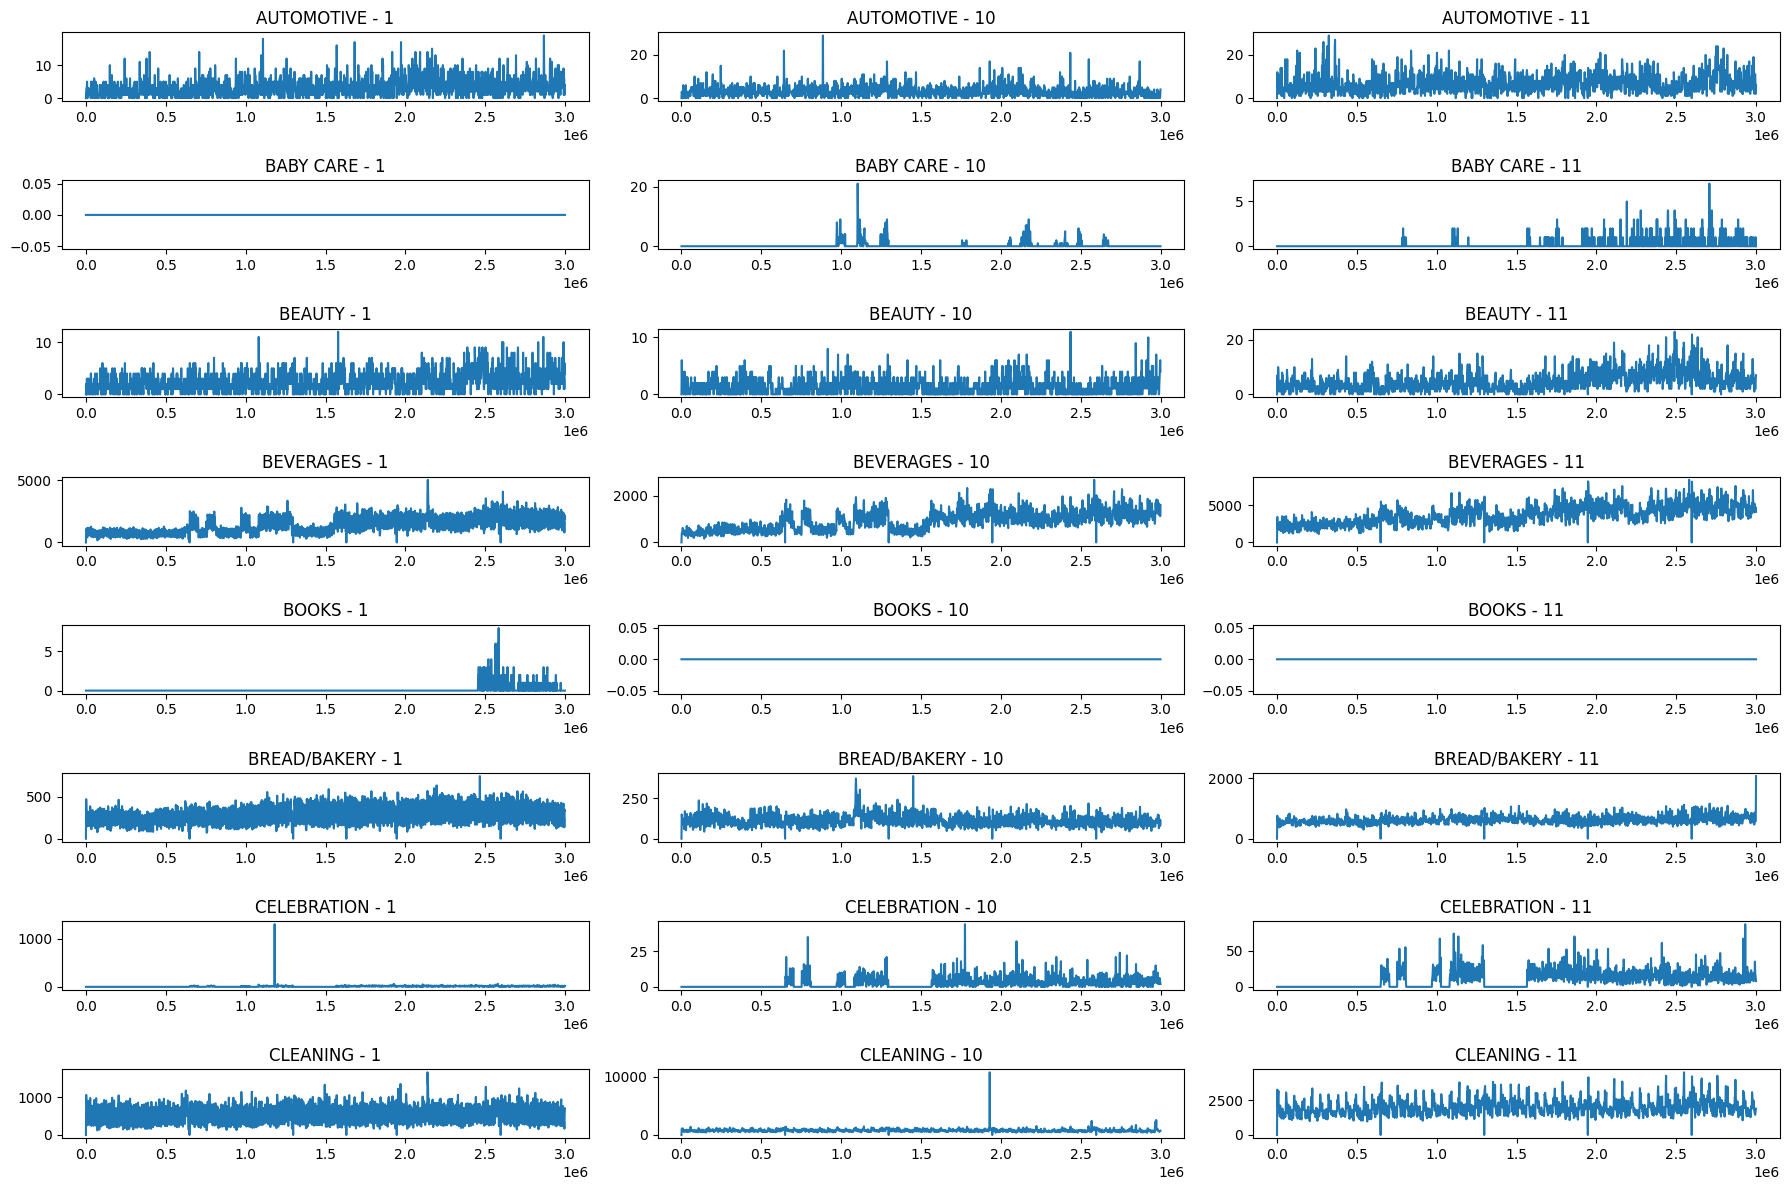

In [ ]:
fig, axs = plt.subplots(8, 3, figsize=(18,12))

for i in range(8):
    for j in range(3):
        ax = axs[i][j]
        ax.set_title(f'{df.family.unique()[i]} - {df.store_nbr.unique()[j]}')
        ax.plot(df[(df.family == df.family.unique()[i]) & (df.store_nbr == df.store_nbr.unique()[j])].sales)

plt.tight_layout()

- Từ biểu đồ ta thấy một số mặt hàng sẽ mang tính thời vụ, một số sẽ không mang tính thời vụ.

- Một số sản phẩm không bán được nhiều, một số sản phẩm không được bán ở các cửa hàng cụ thể, một số trong số chúng có biểu đồ khá hỗn loạn, một số khác có cấu trúc rõ ràng hơn (mang tính thời vụ)



#Preprocessing Data

In [ ]:
scaler = StandardScaler()

train_size = int(0.8 * len(df_pivoted))
train_data = df_pivoted.iloc[:train_size]
test_data = df_pivoted.iloc[train_size:]

train_data_scaled = scaler.fit_transform(train_data)
test_data_scaled = scaler.transform(test_data)

In [ ]:
def create_X_y(data, input_length, output_length):
    X, y = [], []

    for i in range(len(data) - input_length - output_length + 1):
        X.append(data[i:i+input_length])
        y.append(data[i+input_length:i+input_length+output_length])

    return np.array(X), np.array(y)

In [ ]:
X_train, y_train = create_X_y(train_data_scaled, 120, 16)
X_test, y_test = create_X_y(test_data_scaled, 120, 16)

In [ ]:
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(1212, 120, 1782) (1212, 16, 1782)
(202, 120, 1782) (202, 16, 1782)


In [ ]:
X_train_tensor = torch.FloatTensor(X_train).cuda()
y_train_tensor = torch.FloatTensor(y_train).cuda()
X_test_tensor = torch.FloatTensor(X_test).cuda()
y_test_tensor = torch.FloatTensor(y_test).cuda()

In [ ]:
train_data = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)

test_data = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

#Build & Train Model

In [ ]:
class TCNModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv1d(33*54, 64, kernel_size=3, padding=2, dilation=1)  # num_families * num_stores
        self.conv2 = nn.Conv1d(64, 64, kernel_size=3, padding=4, dilation=2) # dilation animated here: https://github.com/vdumoulin/conv_arithmetic/blob/master/README.md
        self.conv3 = nn.Conv1d(64, 64, kernel_size=3, padding=8, dilation=4) # essential idea: longer temporal window without increasing kernel size or depth

        self.fc = nn.Linear(64, 33*54*16)  # num_families * num_stores * num_days_to_predict

    def forward(self, x):
        x = x.transpose(1, 2)  # swaps 2nd and 3rd dimension
        x = F.relu(self.conv1(x)[:, :, :-2])  # Here we remove the extra padded positions
        x = F.relu(self.conv2(x)[:, :, :-4])  # Gives us same temporal length as input
        x = F.relu(self.conv3(x)[:, :, :-8])

        return self.fc(x[:,:,-1]).view(-1, 16, 33*54)  # reshapes (batch_size, 33*54*16) to (batch size, 16, 33*54) (-1 means infer automatically)

In [ ]:
model = TCNModel().cuda()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

In [ ]:
for epoch in range(30):
    model.train()
    epoch_loss = 0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()

        y_pred = model(X_batch)

        loss = torch.sqrt(criterion(y_pred, y_batch))
        loss.backward()

        optimizer.step()

        epoch_loss += loss.item()

    if (epoch+1) % 5 == 0:
        print(f'Epoch {epoch + 1}, Loss: {epoch_loss/len(train_loader)}')

Epoch 5, Loss: 0.7862599366589597
Epoch 10, Loss: 0.7415322724141573
Epoch 15, Loss: 0.7184714878860273
Epoch 20, Loss: 0.7072130755374306
Epoch 25, Loss: 0.6968263826872173
Epoch 30, Loss: 0.6894240928323645


#Evaluate Model

In [ ]:
model.eval()

with torch.no_grad():
    test_pred = model(X_test_tensor)
    test_loss = torch.sqrt(criterion(test_pred, y_test_tensor))
    print(f'Test loss: {test_loss.item()}')

Test loss: 172.23475646972656


In [ ]:
print("Train batch y:", y_batch.min().item(), y_batch.max().item())
print("Test y:", y_test_tensor.min().item(), y_test_tensor.max().item())
print("Train batch y:", y_batch.median().item(), y_batch.mean().item())
print("Test y:", y_test_tensor.median().item(), y_test_tensor.mean().item())
print("Train batch y:", y_batch.quantile(0.99).item(), y_batch.quantile(0.99).item())
print("Test y:", y_test_tensor.quantile(0.99).item(), y_test_tensor.quantile(0.99).item())

Train batch y: -6.216256141662598 35.34794616699219
Test y: -3.338263750076294 10462.0
Train batch y: 0.0 0.18826444447040558
Test y: 0.34021660685539246 7.6906046867370605
Train batch y: 3.4575490951538086 3.4575490951538086
Test y: 10.665324211120605 10.665324211120605


#Train on Full Dataset & Make Predictions

In [ ]:
full_data_scaled = scaler.fit_transform(df_pivoted)

X_full, y_full = create_X_y(full_data_scaled, 120, 16)

X_full_tensor = torch.FloatTensor(X_full).cuda()
y_full_tensor = torch.FloatTensor(y_full).cuda()

full_dataset = TensorDataset(X_full_tensor, y_full_tensor)
full_loader = DataLoader(full_dataset, batch_size=32, shuffle=True)

final_model = TCNModel().cuda()
optimizer = torch.optim.Adam(final_model.parameters(), lr=0.001)

In [ ]:
for epoch in range(30):
    final_model.train()
    epoch_loss = 0

    for X_batch, y_batch in full_loader:
        optimizer.zero_grad()

        y_pred = final_model(X_batch)

        loss = torch.sqrt(criterion(y_pred, y_batch))
        loss.backward()

        optimizer.step()

        epoch_loss += loss.item()

    if (epoch+1) % 5 == 0:
        print(f'Epoch {epoch + 1}, Loss: {epoch_loss/len(full_loader)}')

Epoch 5, Loss: 0.7786931286052782
Epoch 10, Loss: 0.7374649838525422
Epoch 15, Loss: 0.7194110556524627
Epoch 20, Loss: 0.7079300065429843
Epoch 25, Loss: 0.6992235621627496
Epoch 30, Loss: 0.6913270512405707


In [ ]:
final_model.eval()

with torch.no_grad():
    last_sequence = torch.FloatTensor(full_data_scaled[-120:]).unsqueeze(0).cuda()
    predictions = final_model(last_sequence)

predictions = predictions.cpu().numpy().squeeze(0)
predictions = scaler.inverse_transform(predictions)
predictions = np.maximum(predictions, 0) # Clip negative sales to 0

test_df = pd.read_csv('data/test.csv')
test_df['store_family'] = test_df['store_nbr'].astype(str) + '_' + test_df['family']
dates = sorted(test_df['date'].unique())

pred_df = pd.DataFrame(predictions, index=dates, columns=df_pivoted.columns)

pred_long = pred_df.stack().reset_index()  # opposite of pivot basically
pred_long.columns = ['date', 'store_family', 'sales']

submission = test_df.merge(pred_long, on=['date', 'store_family'], how='left')[['id', 'sales']]
submission.to_csv('submission.csv', index=False)

print("Predictions saved to submission.csv")

Predictions saved to submission.csv


#So sánh với các mô hình khác: LSTM, ARIMA, XGBoost

Ngoài TCN, ta xây dựng thêm:
- **LSTM**: cùng cách tiếp cận đa chuỗi thời gian (dự báo đồng thời 33*54 chuỗi) giống hệt TCN, chỉ khác kiến trúc, để so sánh công bằng trên cùng train_loader/test_loader.
- **ARIMA** và **XGBoost**: đây là các mô hình truyền thống, huấn luyện riêng cho từng chuỗi sẽ rất tốn thời gian (1782 chuỗi). Vì vậy ta áp dụng chúng trên chuỗi tổng doanh số toàn hệ thống (tổng tất cả store_family theo ngày) để có một phép so sánh công bằng, dễ diễn giải giữa 4 mô hình.




###Xây dựng & huấn luyện mô hình LSTM

In [ ]:
class LSTMModel(nn.Module):
    def __init__(self, num_series=33*54, hidden_size=128, num_layers=2, output_length=16):
        super().__init__()
        self.output_length = output_length
        self.num_series = num_series

        self.lstm = nn.LSTM(input_size=num_series, hidden_size=hidden_size, num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_series * output_length)

    def forward(self, x):
        out, (h_n, c_n) = self.lstm(x)  # out: (batch, seq_len, hidden_size)
        last_hidden = out[:, -1, :]  # lấy hidden state ở bước thời gian cuối cùng

        return self.fc(last_hidden).view(-1, self.output_length, self.num_series)

lstm_model = LSTMModel().cuda()
lstm_optimizer = torch.optim.Adam(lstm_model.parameters(), lr=0.001)
criterion = nn.MSELoss()

for epoch in range(30):
    lstm_model.train()
    epoch_loss = 0

    for X_batch, y_batch in train_loader:
        lstm_optimizer.zero_grad()

        y_pred = lstm_model(X_batch)

        loss = torch.sqrt(criterion(y_pred, y_batch))
        loss.backward()

        lstm_optimizer.step()

        epoch_loss += loss.item()

    if (epoch+1) % 5 == 0:
        print(f'[LSTM] Epoch {epoch + 1}, Loss: {epoch_loss/len(train_loader)}')

[LSTM] Epoch 5, Loss: 0.7688347603145399
[LSTM] Epoch 10, Loss: 0.7091224789619446
[LSTM] Epoch 15, Loss: 0.6762008949329978
[LSTM] Epoch 20, Loss: 0.6560583710670471
[LSTM] Epoch 25, Loss: 0.6428464525624326
[LSTM] Epoch 30, Loss: 0.6324826463272697


In [ ]:
##Đánh giá LSTM trên tập test

lstm_model.eval()

with torch.no_grad():
    lstm_test_pred = lstm_model(X_test_tensor)
    lstm_test_loss = torch.sqrt(criterion(lstm_test_pred, y_test_tensor))
    print(f'LSTM Test loss: {lstm_test_loss.item()}')

LSTM Test loss: 172.1747283935547


- Chuẩn bị chuỗi tổng doanh số cho ARIMA & XGBoost

Ta lấy 120 ngày cuối cùng của tập train để dự báo 16 ngày đầu tiên của tập test - cùng độ dài input/output như TCN/LSTM, giúp so sánh công bằng giữa 4 mô hình trên cùng một cửa sổ dự báo.


In [ ]:
total_sales = df_pivoted.sum(axis=1)  # tổng doanh số tất cả store_family theo từng ngày

train_total = total_sales.iloc[:train_size]
test_total = total_sales.iloc[train_size:]

horizon = 16
actual_future = test_total.iloc[:horizon].values

print(train_total.shape, test_total.shape, actual_future.shape)

(1347,) (337,) (16,)


###Mô hình ARIMA

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

# order=(p,d,q): d=1 để khử xu hướng (trend) trong chuỗi doanh số
arima_model = ARIMA(train_total, order=(5, 1, 0)).fit()
arima_forecast = arima_model.forecast(steps=horizon).values

print(arima_forecast)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


[876955.43116393 812638.7462654  753537.13347934 684342.40324529
 746348.71627789 890446.4581186  902346.39282235 848653.65054852
 818108.15128056 771991.67347615 737644.45996923 793362.60841308
 856391.40340904 854620.18547838 834267.17683593 817417.64940383]


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


###Mô hình XGBoost (dự báo đa bước với lag features, cùng tư duy create_X_y)

In [ ]:
from xgboost import XGBRegressor
from sklearn.multioutput import MultiOutputRegressor

def create_X_y_1d(series, input_length, output_length):
    X, y = [], []

    for i in range(len(series) - input_length - output_length + 1):
        X.append(series[i:i+input_length])
        y.append(series[i+input_length:i+input_length+output_length])

    return np.array(X), np.array(y)

X_train_xgb, y_train_xgb = create_X_y_1d(train_total.values, 120, horizon)
print(X_train_xgb.shape, y_train_xgb.shape)

xgb_model = MultiOutputRegressor(
    XGBRegressor(n_estimators=300, max_depth=5, learning_rate=0.05, random_state=42)
)
xgb_model.fit(X_train_xgb, y_train_xgb)

xgb_forecast_input = train_total.values[-120:].reshape(1, -1)
xgb_forecast = xgb_model.predict(xgb_forecast_input)[0]

print(xgb_forecast)

(1212, 120) (1212, 16)
[ 767312.56  640089.94  699373.7   613082.4   731908.75  966815.4
 1017114.5   790155.9   724055.    718645.06  653336.    716994.7
  860480.4   915552.    701248.25  659238.44]


###Dự báo TCN & LSTM trên cùng cửa sổ (120 ngày cuối train → 16 ngày đầu test)

- TCN và LSTM dự báo đồng thời cho từng store_family (đang ở scaled space), nên cần inverse_transform về giá trị gốc rồi cộng dồn tất cả các chuỗi lại thành tổng doanh số để so sánh với ARIMA/XGBoost.

Lưu ý: biến `scaler` ở phần "Train on Full Dataset & Make Predictions" phía trên đã được fit lại trên toàn bộ dữ liệu, nên không thể dùng lại để inverse_transform cho phần so sánh này (vốn cần scaler fit trên train). Ta tạo riêng `train_scaler` fit trên đúng phần train ban đầu để đảm bảo kết quả chính xác.

In [ ]:
train_scaler = StandardScaler().fit(df_pivoted.iloc[:train_size])

forecast_input_scaled = train_data_scaled[-120:]
forecast_input_tensor = torch.FloatTensor(forecast_input_scaled).unsqueeze(0).cuda()

model.eval()
with torch.no_grad():
    tcn_pred_scaled = model(forecast_input_tensor).cpu().numpy().squeeze(0)
tcn_pred = train_scaler.inverse_transform(tcn_pred_scaled)
tcn_forecast = tcn_pred.sum(axis=1)  # tổng theo tất cả store_family

lstm_model.eval()
with torch.no_grad():
    lstm_pred_scaled = lstm_model(forecast_input_tensor).cpu().numpy().squeeze(0)
lstm_pred = train_scaler.inverse_transform(lstm_pred_scaled)
lstm_forecast = lstm_pred.sum(axis=1)

print('TCN:', tcn_forecast)
print('LSTM:', lstm_forecast)

TCN: [ 669387.4   656815.1   652042.8   515337.84  710049.1  1077380.2
 1068701.    809869.6   801366.94  798703.    616729.25  726481.5
 1011514.9   975926.1   724278.8   728541.7 ]
LSTM: [823471.3  801149.4  780664.9  626119.9  695774.2  955468.56 984984.25
 735540.94 691120.5  689133.75 569408.75 667030.1  896847.75 933972.75
 681230.94 654641.25]


##Đánh giá & so sánh các mô hình

In [ ]:

from sklearn.metrics import mean_squared_error, mean_absolute_error

def evaluate_forecast(actual, predicted):
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mae = mean_absolute_error(actual, predicted)
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    return rmse, mae, mape

results = {
    'ARIMA': evaluate_forecast(actual_future, arima_forecast),
    'XGBoost': evaluate_forecast(actual_future, xgb_forecast),
    'TCN': evaluate_forecast(actual_future, tcn_forecast),
    'LSTM': evaluate_forecast(actual_future, lstm_forecast),
}

comparison_df = pd.DataFrame(results, index=['RMSE', 'MAE', 'MAPE (%)']).T
comparison_df = comparison_df.sort_values('RMSE')
comparison_df

,RMSE,MAE,MAPE (%)
XGBoost,65175.403629,56742.211533,8.733263
LSTM,80943.952574,58984.416690,9.005656
TCN,98391.050033,82559.532086,11.938981
ARIMA,147174.483404,131791.763442,20.291384


##Trực quan hóa kết quả so sánh

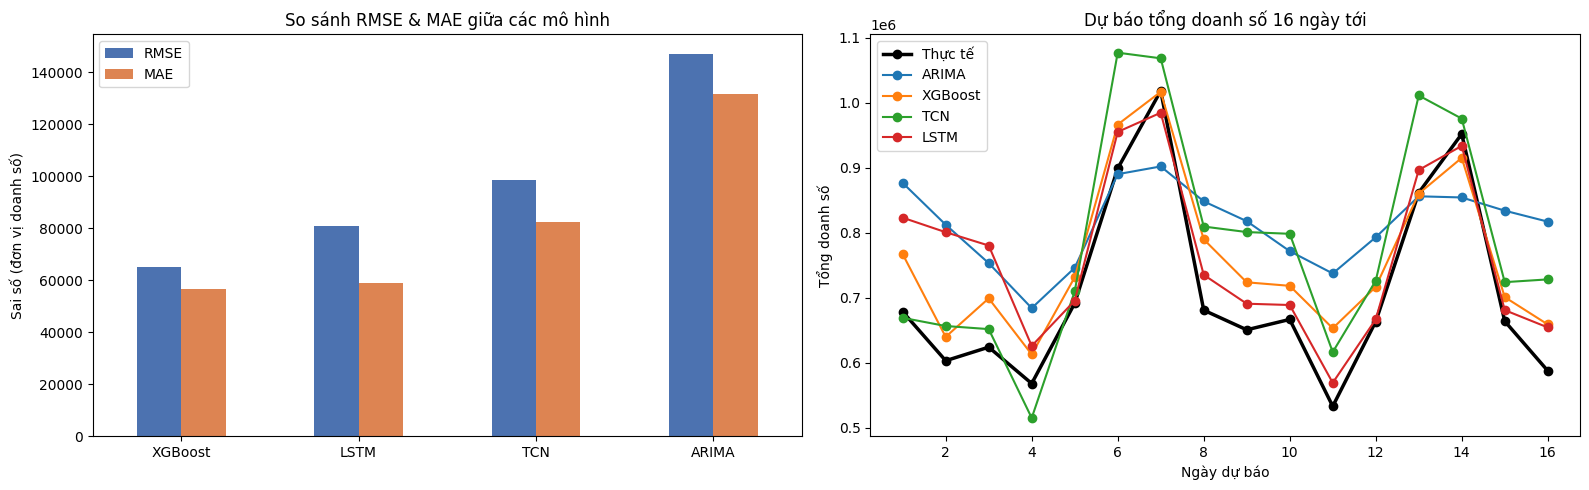

Mô hình tốt nhất theo RMSE: XGBoost


In [ ]:

fig, axs = plt.subplots(1, 2, figsize=(16, 5))

comparison_df[['RMSE', 'MAE']].plot(kind='bar', ax=axs[0], color=['#4C72B0', '#DD8452'])
axs[0].set_title('So sánh RMSE & MAE giữa các mô hình')
axs[0].set_ylabel('Sai số (đơn vị doanh số)')
axs[0].tick_params(axis='x', rotation=0)

axs[1].plot(range(1, horizon+1), actual_future, label='Thực tế', marker='o', linewidth=2.5, color='black')
axs[1].plot(range(1, horizon+1), arima_forecast, label='ARIMA', marker='o')
axs[1].plot(range(1, horizon+1), xgb_forecast, label='XGBoost', marker='o')
axs[1].plot(range(1, horizon+1), tcn_forecast, label='TCN', marker='o')
axs[1].plot(range(1, horizon+1), lstm_forecast, label='LSTM', marker='o')
axs[1].set_title('Dự báo tổng doanh số 16 ngày tới')
axs[1].set_xlabel('Ngày dự báo')
axs[1].set_ylabel('Tổng doanh số')
axs[1].legend()

plt.tight_layout()
plt.show()

print(f"Mô hình tốt nhất theo RMSE: {comparison_df['RMSE'].idxmin()}")